In [1]:
print("=" * 50)
print("Environment Setup and Dataset Upload")
print("=" * 50)

# Install required libraries
!pip install -q networkx pandas matplotlib seaborn python-louvain

from google.colab import files
import zipfile
import os

# Upload your local polblogs.zip file
uploaded = files.upload()

# Extract the uploaded zip archive
for filename in uploaded.keys():
    if filename.endswith('.zip'):
        with zipfile.ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall(".")
        print(f"Extracted {filename} successfully.")

Environment Setup and Dataset Upload


Saving polblogs.zip to polblogs (1).zip
Extracted polblogs (1).zip successfully.


Part A: Dataset and Graph Construction
Raw Multigraph Nodes: 1490
Raw Multigraph Edges: 19090
Converted Simple DiGraph Nodes: 1490
Converted Simple DiGraph Edges (after duplicate removal): 19025
Is Directed: True
Is Multigraph: False
Preprocessed Nodes: 1490
Preprocessed Edges: 19022
Graph Density: 0.008574
Weakly Connected Components: 268
Strongly Connected Components: 688


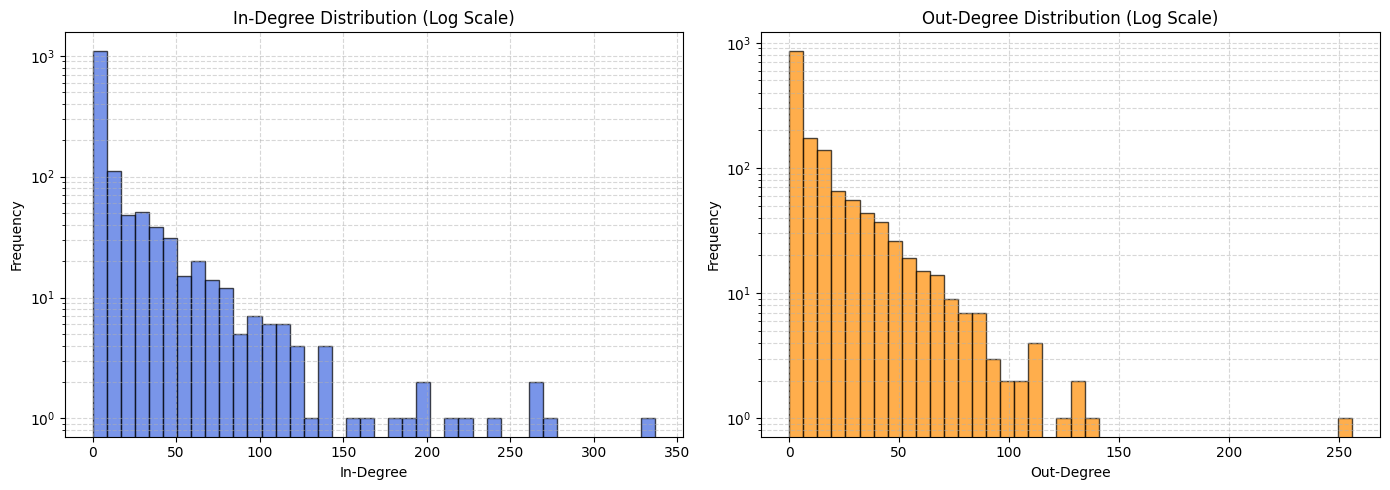

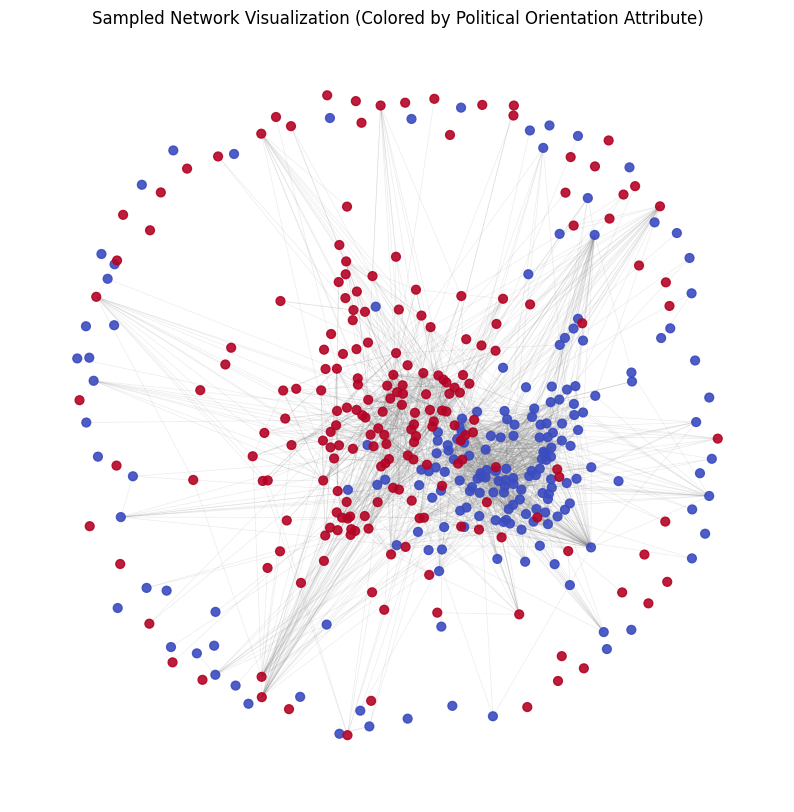

In [4]:
print("=" * 50)
print("Part A: Dataset and Graph Construction")
print("=" * 50)

import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import random

# Patch polblogs.gml header to support multigraph parsing for duplicate edges
with open("polblogs.gml", "r") as f:
    lines = f.readlines()

for i, line in enumerate(lines):
    if "graph [" in line:
        lines.insert(i + 1, "  multigraph 1\n")
        break

with open("polblogs.gml", "w") as f:
    f.writelines(lines)

# Load graph as MultiDiGraph to handle duplicate edges present in the raw file[cite: 1]
G_multigraph = nx.read_gml("polblogs.gml", label="id")
print(f"Raw Multigraph Nodes: {G_multigraph.number_of_nodes()}")
print(f"Raw Multigraph Edges: {G_multigraph.number_of_edges()}")

# Convert to standard DiGraph (collapsing parallel duplicate edges)
G_raw = nx.DiGraph(G_multigraph)
print(f"Converted Simple DiGraph Nodes: {G_raw.number_of_nodes()}")
print(f"Converted Simple DiGraph Edges (after duplicate removal): {G_raw.number_of_edges()}")
print(f"Is Directed: {G_raw.is_directed()}")
print(f"Is Multigraph: {G_raw.is_multigraph()}")

# Preprocessing: Remove self-loops[cite: 1]
G = G_raw.copy()
self_loops = list(nx.selfloop_edges(G))
G.remove_edges_from(self_loops)

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
density = nx.density(G)
wcc_count = len(list(nx.weakly_connected_components(G)))
scc_count = len(list(nx.strongly_connected_components(G)))

print(f"Preprocessed Nodes: {num_nodes}")
print(f"Preprocessed Edges: {num_edges}")
print(f"Graph Density: {density:.6f}")
print(f"Weakly Connected Components: {wcc_count}")
print(f"Strongly Connected Components: {scc_count}")

# 1. Clean, Non-Overlapping Degree Distribution Figure (Side-by-side Subplots)
in_degrees = [d for n, d in G.in_degree()]
out_degrees = [d for n, d in G.out_degree()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(in_degrees, bins=40, color='royalblue', edgecolor='black', alpha=0.7)
axes[0].set_yscale('log')
axes[0].set_title('In-Degree Distribution (Log Scale)')
axes[0].set_xlabel('In-Degree')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, which="both", ls="--", alpha=0.5)

axes[1].hist(out_degrees, bins=40, color='darkorange', edgecolor='black', alpha=0.7)
axes[1].set_yscale('log')
axes[1].set_title('Out-Degree Distribution (Log Scale)')
axes[1].set_xlabel('Out-Degree')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

# 2. Readable Network Visualization (Sampled cleanly as permitted for visualization)[cite: 1]
plt.figure(figsize=(10, 10))
largest_wcc = max(nx.weakly_connected_components(G), key=len)
G_sub = G.subgraph(largest_wcc).copy()

# Sample subset of nodes for clarity to prevent hairball overlapping
if G_sub.number_of_nodes() > 400:
    sampled_nodes = random.sample(list(G_sub.nodes()), 400)
    G_vis = G_sub.subgraph(sampled_nodes)
else:
    G_vis = G_sub

node_colors = [G_vis.nodes[n].get('value', 0) for n in G_vis.nodes()]
pos = nx.spring_layout(G_vis, seed=42, k=0.15)

nx.draw_networkx_nodes(G_vis, pos, node_size=40, node_color=node_colors, cmap=plt.cm.coolwarm, alpha=0.9)
nx.draw_networkx_edges(G_vis, pos, alpha=0.15, edge_color='gray', width=0.5, arrows=False)
plt.title("Sampled Network Visualization (Colored by Political Orientation Attribute)")
plt.axis('off')
plt.show()

In [5]:
print("=" * 50)
print("Part B: Centrality Selection and Analysis")
print("=" * 50)

# Compute PageRank and Betweenness Centrality[cite: 1]
pagerank_scores = nx.pagerank(G, alpha=0.85)
betweenness_scores = nx.betweenness_centrality(G, normalized=True)

# Convert scores to DataFrames for ranking[cite: 1]
df_pr = pd.DataFrame(list(pagerank_scores.items()), columns=['Node', 'PageRank']).sort_values(by='PageRank', ascending=False)
df_bc = pd.DataFrame(list(betweenness_scores.items()), columns=['Node', 'Betweenness']).sort_values(by='Betweenness', ascending=False)

print("Top 10 Nodes by PageRank:")
print(df_pr.head(10).to_markdown(index=False))

print("\nTop 10 Nodes by Betweenness Centrality:")
print(df_bc.head(10).to_markdown(index=False))

# Compare rankings using Spearman correlation[cite: 1]
merged_df = pd.merge(df_pr, df_bc, on='Node')
merged_df['PR_Rank'] = merged_df['PageRank'].rank(ascending=False)
merged_df['BC_Rank'] = merged_df['Betweenness'].rank(ascending=False)

spearman_corr = merged_df['PR_Rank'].corr(merged_df['BC_Rank'], method='spearman')
print(f"\nSpearman Rank Correlation between PageRank and Betweenness: {spearman_corr:.4f}")

Part B: Centrality Selection and Analysis
Top 10 Nodes by PageRank:
|   Node |   PageRank |
|-------:|-----------:|
|    155 | 0.0179373  |
|     55 | 0.0152087  |
|   1051 | 0.0126517  |
|    855 | 0.0125337  |
|    641 | 0.0124177  |
|   1153 | 0.0109403  |
|    963 | 0.0107345  |
|    729 | 0.0105324  |
|   1245 | 0.00895682 |
|    798 | 0.00862497 |

Top 10 Nodes by Betweenness Centrality:
|   Node |   Betweenness |
|-------:|--------------:|
|    855 |     0.0986012 |
|     55 |     0.0410654 |
|   1051 |     0.0344236 |
|    155 |     0.0248155 |
|    454 |     0.0207144 |
|    387 |     0.02032   |
|   1479 |     0.0183256 |
|   1101 |     0.0163094 |
|   1041 |     0.0154582 |
|    729 |     0.0147407 |

Spearman Rank Correlation between PageRank and Betweenness: 0.8095


In [6]:
print("=" * 50)
print("Part C: Centrality-Informed Experiment")
print("=" * 50)

import random
import numpy as np

# Set fixed random seed for reproducibility[cite: 1]
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

removal_fraction = 0.05
num_to_remove = int(num_nodes * removal_fraction)

# Targeted graph removal based on top PageRank nodes[cite: 1]
top_pr_nodes = df_pr['Node'].head(num_to_remove).tolist()
G_targeted = G.copy()
G_targeted.remove_nodes_from(top_pr_nodes)

# Random graph removal with fixed seed[cite: 1]
all_nodes = list(G.nodes())
random_nodes = random.sample(all_nodes, num_to_remove)
G_random = G.copy()
G_random.remove_nodes_from(random_nodes)

print(f"Original Graph - Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")
print(f"Targeted Removal Graph - Nodes: {G_targeted.number_of_nodes()}, Edges: {G_targeted.number_of_edges()}")
print(f"Random Removal Graph - Nodes: {G_random.number_of_nodes()}, Edges: {G_random.number_of_edges()}")

Part C: Centrality-Informed Experiment
Original Graph - Nodes: 1490, Edges: 19022
Targeted Removal Graph - Nodes: 1416, Edges: 9235
Random Removal Graph - Nodes: 1416, Edges: 16851
